# Gene essentiality model — interactive training

Train the MLP on ProteomeLM embeddings (3-class or binary). Change the config and hyperparameters in the next cells, then run the training and evaluation cells.

In [25]:
import json
import sys
from pathlib import Path

import torch
import yaml
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader

project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.model import create_datasets_from_config
from src.model.network import EssentialityMLP
from src.model.train import (
    collect_predictions,
    compute_metrics,
    default_class_names,
    eval_epoch,
    make_loss_fn,
    train_epoch,
)

## Configuration

Set config path (3-class: `config/model.yaml`, binary: `config/model_binary.yaml`) and training hyperparameters.

In [26]:
config_path = project_root / "config" / "model_binary.yaml"  # or "model.yaml" for 3-class
output_name = "notebook_model"

epochs = 100
batch_size = 512
lr = 1e-3
dropout = 0.2
weight_decay = 1e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

early_stopping = 15
early_stop_on = "auprc"  # "loss" or "auprc" (best checkpoint = highest essential AUPRC)
use_scheduler = True
scheduler_patience = 5
scheduler_factor = 0.5

## Load data

Create train/val/test datasets and dataloaders from the config.

In [27]:
train_ds, val_ds, test_ds = create_datasets_from_config(config_path, normalize_by_organism=True)
n_classes = train_ds.n_classes

with open(config_path) as f:
    cfg = yaml.safe_load(f)
class_names = cfg.get("classification", {}).get("class_names")
if not class_names or len(class_names) != n_classes:
    class_names = default_class_names(n_classes)

print(f"Classes: {n_classes} ({', '.join(class_names)})")
print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

for name, ds in [("Train", train_ds), ("Val", val_ds), ("Test", test_ds)]:
    counts = torch.bincount(ds.get_labels(), minlength=n_classes)
    total = counts.sum().item()
    parts = [f"{class_names[c]}: {counts[c].item()} ({100 * counts[c].item() / total:.1f}%)" for c in range(n_classes)]
    print(f"  {name}: {', '.join(parts)}")

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

Classes: 2 (essential, non_essential)
Train: 78663  Val: 17620  Test: 16577
  Train: essential: 13561 (17.2%), non_essential: 65102 (82.8%)
  Val: essential: 2463 (14.0%), non_essential: 15157 (86.0%)
  Test: essential: 3029 (18.3%), non_essential: 13548 (81.7%)


## Model and loss

Build the MLP and cross-entropy loss with class weights from the training set.

In [28]:
loss_fn = make_loss_fn(train_ds.get_labels(), n_classes=n_classes, device=device)
model = EssentialityMLP(
    input_dim=train_ds.embedding_dim,
    n_classes=n_classes,
    dropout=dropout,
).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

## Training loop

Runs for `epochs` with optional early stopping on validation loss or essential AUPRC. Best checkpoint is saved to `models/<output_name>.pth`.

In [29]:
use_auprc = early_stop_on in ("auprc", "auprc_ae")
auprc_key = f"auprc_{class_names[0]}"
scheduler = None
if use_scheduler:
    scheduler = ReduceLROnPlateau(
        optimizer, mode="max" if use_auprc else "min",
        factor=scheduler_factor, patience=scheduler_patience,
    )

best_val_metric = float("-inf") if use_auprc else float("inf")
epochs_without_improvement = 0
train_losses, val_losses, val_metrics_history = [], [], []
checkpoint_path = project_root / "models" / f"{output_name}.pth"
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, loss_fn, optimizer, device)
    val_loss = eval_epoch(model, val_loader, loss_fn, device)
    logits, labels = collect_predictions(model, val_loader, device)
    val_metrics = compute_metrics(logits, labels, n_classes=n_classes, class_names=class_names)

    metric_parts = [f"acc={val_metrics['accuracy']:.3f}", f"F1={val_metrics['weighted_f1']:.3f}"]
    for name in class_names:
        v = val_metrics.get(f"auprc_{name}")
        metric_parts.append(f"AUPRC_{name[:4]}={v:.3f}" if isinstance(v, float) else f"AUPRC_{name[:4]}={v}")
    for name in class_names:
        v = val_metrics.get(f"auroc_{name}")
        metric_parts.append(f"AUROC_{name[:4]}={v:.3f}" if isinstance(v, float) else f"AUROC_{name[:4]}={v}")
    lr_str = f" lr={optimizer.param_groups[0]['lr']:.2e}" if scheduler else ""
    print(f"Epoch {epoch:3d}: train={train_loss:.4f} val={val_loss:.4f} | {' '.join(metric_parts)}{lr_str}")

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_metrics_history.append(val_metrics)

    if scheduler is not None:
        if use_auprc:
            scheduler.step(val_metrics.get(auprc_key) or 0.0)
        else:
            scheduler.step(val_loss)

    if use_auprc:
        current = val_metrics.get(auprc_key) or 0.0
        improved = current > best_val_metric
    else:
        current = val_loss
        improved = current < best_val_metric

    if improved:
        best_val_metric = current
        epochs_without_improvement = 0
        torch.save(model.state_dict(), checkpoint_path)
    else:
        epochs_without_improvement += 1

    if early_stopping is not None and epochs_without_improvement >= early_stopping:
        print(f"Early stopping at epoch {epoch} (no improvement for {early_stopping} epochs)")
        break

Epoch   0: train=0.5916 val=0.5814 | acc=0.742 F1=0.773 AUPRC_esse=0.376 AUPRC_non_=0.941 AUC_esse=0.746 AUC_non_=0.746 lr=1.00e-03
Epoch   1: train=0.5555 val=0.5743 | acc=0.725 F1=0.762 AUPRC_esse=0.392 AUPRC_non_=0.943 AUC_esse=0.756 AUC_non_=0.756 lr=1.00e-03
Epoch   2: train=0.5218 val=0.5749 | acc=0.773 F1=0.796 AUPRC_esse=0.415 AUPRC_non_=0.943 AUC_esse=0.756 AUC_non_=0.756 lr=1.00e-03
Epoch   3: train=0.4881 val=0.5763 | acc=0.714 F1=0.755 AUPRC_esse=0.444 AUPRC_non_=0.948 AUC_esse=0.774 AUC_non_=0.774 lr=1.00e-03
Epoch   4: train=0.4510 val=0.5833 | acc=0.754 F1=0.784 AUPRC_esse=0.440 AUPRC_non_=0.947 AUC_esse=0.770 AUC_non_=0.770 lr=1.00e-03
Epoch   5: train=0.4130 val=0.6095 | acc=0.719 F1=0.758 AUPRC_esse=0.451 AUPRC_non_=0.947 AUC_esse=0.774 AUC_non_=0.774 lr=1.00e-03
Epoch   6: train=0.3743 val=0.6318 | acc=0.725 F1=0.762 AUPRC_esse=0.436 AUPRC_non_=0.947 AUC_esse=0.771 AUC_non_=0.771 lr=1.00e-03
Epoch   7: train=0.3413 val=0.7784 | acc=0.757 F1=0.786 AUPRC_esse=0.436 AUP

## Training curves

Plot loss and optionally validation AUPRC over epochs.

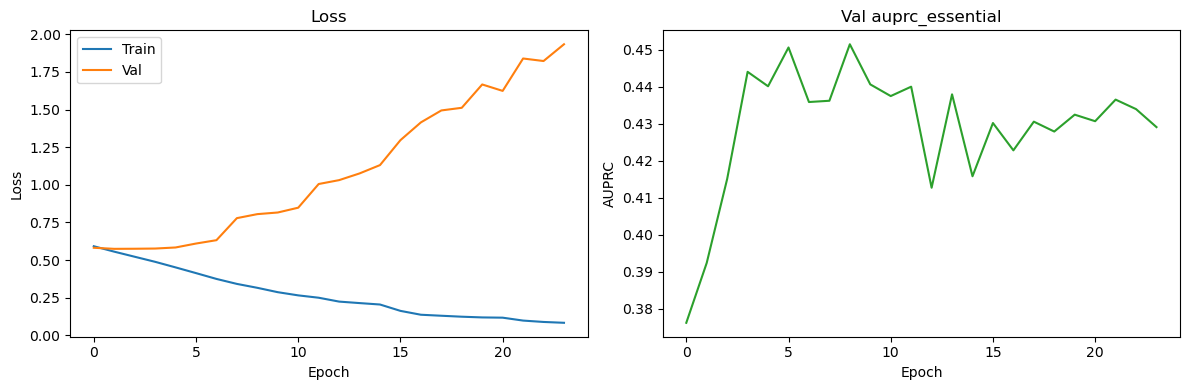

In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, label="Train")
axes[0].plot(val_losses, label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()

auprc_vals = [m.get(auprc_key) if m.get(auprc_key) is not None else float("nan") for m in val_metrics_history]
axes[1].plot(auprc_vals, color="C2")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUPRC")
axes[1].set_title(f"Val {auprc_key}")
plt.tight_layout()
plt.show()

## Test set evaluation

Load the best checkpoint and compute metrics on the test set.

In [32]:
model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
test_logits, test_labels = collect_predictions(model, test_loader, device)
test_metrics = compute_metrics(test_logits, test_labels, n_classes=n_classes, class_names=class_names)

print(f"=== Test set (checkpoint: {checkpoint_path.name}) ===")
for name in class_names:
    auroc = test_metrics.get(f"auroc_{name}")
    print(f"  AUROC ({name}): {auroc}")
for k, v in test_metrics.items():
    print(f"  {k}: {v}")

=== Test set (checkpoint: notebook_model.pth) ===
  AUC (essential): 0.7244889915152445
  AUC (non_essential): 0.7244585433029382
  accuracy: 0.7310731736743681
  weighted_f1: 0.7514738142968355
  auroc_essential: 0.7244889915152445
  auprc_essential: 0.43754580550677447
  auroc_non_essential: 0.7244585433029382
  auprc_non_essential: 0.9076486957167795


## Parameter sweep

Optional: run a grid over lr, dropout, weight decay, architecture (hidden_dims), batch size, scheduler, and class weighting. Same data and config (epochs, early stopping, etc.) as above. Best val AUPRC per run recorded; best checkpoint saved. Shrink lists to reduce runs.


In [13]:
import itertools
import pandas as pd
import torch.nn as nn

sweep_lr = [1e-3, 3e-4]
sweep_dropout = [0.2, 0.3]
sweep_weight_decay = [1e-4]
sweep_hidden_dims = [[256, 128], [512, 256], [512, 256, 128]]
sweep_batch_size = [256, 512]
sweep_scheduler_patience = [5]
sweep_scheduler_factor = [0.5]
sweep_use_class_weights = [True, False]

sweep_grid = list(itertools.product(
    sweep_lr, sweep_dropout, sweep_weight_decay, sweep_hidden_dims,
    sweep_batch_size, sweep_scheduler_patience, sweep_scheduler_factor, sweep_use_class_weights,
))
print(f"Total runs: {len(sweep_grid)}")

auprc_key_sweep = f"auprc_{class_names[0]}"
sweep_results = []
best_overall_auprc = float("-inf")
sweep_checkpoint_path = project_root / "models" / f"{output_name}_sweep_best.pth"

for run_idx, (lr_run, drop_run, wd_run, hidden_dims_run, bs_run, sched_pat_run, sched_fac_run, use_cw_run) in enumerate(sweep_grid):
    train_loader_run = DataLoader(train_ds, batch_size=bs_run, shuffle=True)
    val_loader_run = DataLoader(val_ds, batch_size=bs_run, shuffle=False)
    test_loader_run = DataLoader(test_ds, batch_size=bs_run, shuffle=False)
    if use_cw_run:
        loss_fn_run = make_loss_fn(train_ds.get_labels(), n_classes=n_classes, device=device)
    else:
        loss_fn_run = nn.CrossEntropyLoss().to(device)

    model_run = EssentialityMLP(
        input_dim=train_ds.embedding_dim,
        hidden_dims=hidden_dims_run,
        n_classes=n_classes,
        dropout=drop_run,
    ).to(device)
    opt_run = torch.optim.AdamW(model_run.parameters(), lr=lr_run, weight_decay=wd_run)
    sched_run = None
    if use_scheduler:
        sched_run = ReduceLROnPlateau(opt_run, mode="max", factor=sched_fac_run, patience=sched_pat_run)

    best_auprc = float("-inf")
    epochs_no_improve = 0
    run_checkpoint = project_root / "models" / f"{output_name}_sweep_temp.pth"

    for ep in range(epochs):
        train_epoch(model_run, train_loader_run, loss_fn_run, opt_run, device)
        val_loss = eval_epoch(model_run, val_loader_run, loss_fn_run, device)
        logits, labels = collect_predictions(model_run, val_loader_run, device)
        val_m = compute_metrics(logits, labels, n_classes=n_classes, class_names=class_names)
        current_auprc = val_m.get(auprc_key_sweep) or 0.0
        if sched_run is not None:
            sched_run.step(current_auprc)
        if current_auprc > best_auprc:
            best_auprc = current_auprc
            epochs_no_improve = 0
            torch.save(model_run.state_dict(), run_checkpoint)
            if current_auprc > best_overall_auprc:
                best_overall_auprc = current_auprc
                torch.save(model_run.state_dict(), sweep_checkpoint_path)
        else:
            epochs_no_improve += 1
        if early_stopping is not None and epochs_no_improve >= early_stopping:
            break

    model_run.load_state_dict(torch.load(run_checkpoint, map_location=device, weights_only=True))
    test_logits_run, test_labels_run = collect_predictions(model_run, test_loader_run, device)
    test_m = compute_metrics(test_logits_run, test_labels_run, n_classes=n_classes, class_names=class_names)
    sweep_results.append({
        "lr": lr_run, "dropout": drop_run, "weight_decay": wd_run,
        "hidden_dims": str(hidden_dims_run), "batch_size": bs_run,
        "sched_patience": sched_pat_run, "sched_factor": sched_fac_run, "use_class_weights": use_cw_run,
        "best_val_auprc": best_auprc,
        "test_accuracy": test_m["accuracy"],
        "test_auprc_essential": test_m.get(auprc_key_sweep),
        "test_auroc_essential": test_m.get(f"auroc_{class_names[0]}"),
    })
    print(f"Run {run_idx + 1}/{len(sweep_grid)} lr={lr_run} drop={drop_run} hd={hidden_dims_run} bs={bs_run} cw={use_cw_run} -> val_auprc={best_auprc:.4f} test_auprc={test_m.get(auprc_key_sweep)} test_auroc={test_m.get(f'auroc_{class_names[0]}')}")

df_sweep = pd.DataFrame(sweep_results)
df_sweep = df_sweep.sort_values("best_val_auprc", ascending=False).reset_index(drop=True)
display(df_sweep)
best = df_sweep.iloc[0]
print(f"\nBest run by val AUPRC: lr={best['lr']} dropout={best['dropout']} weight_decay={best['weight_decay']} hidden_dims={best['hidden_dims']} batch_size={best['batch_size']} use_class_weights={best['use_class_weights']}")
print(f"Best checkpoint (if improved): {sweep_checkpoint_path}")

Total runs: 48
Run 1/48 lr=0.001 drop=0.2 hd=[256, 128] bs=256 cw=True -> val_auprc=0.4547 test_auprc=0.44263234796457024
Run 2/48 lr=0.001 drop=0.2 hd=[256, 128] bs=256 cw=False -> val_auprc=0.4614 test_auprc=0.4510607458320483
Run 3/48 lr=0.001 drop=0.2 hd=[256, 128] bs=512 cw=True -> val_auprc=0.4516 test_auprc=0.446412839742551
Run 4/48 lr=0.001 drop=0.2 hd=[256, 128] bs=512 cw=False -> val_auprc=0.4586 test_auprc=0.43460585039570054
Run 5/48 lr=0.001 drop=0.2 hd=[512, 256] bs=256 cw=True -> val_auprc=0.4552 test_auprc=0.45671874857928196
Run 6/48 lr=0.001 drop=0.2 hd=[512, 256] bs=256 cw=False -> val_auprc=0.4722 test_auprc=0.4444426991757741
Run 7/48 lr=0.001 drop=0.2 hd=[512, 256] bs=512 cw=True -> val_auprc=0.4338 test_auprc=0.4447591725194322
Run 8/48 lr=0.001 drop=0.2 hd=[512, 256] bs=512 cw=False -> val_auprc=0.4631 test_auprc=0.4374136503517209
Run 9/48 lr=0.001 drop=0.2 hd=[512, 256, 128] bs=256 cw=True -> val_auprc=0.4609 test_auprc=0.44772932982527447
Run 10/48 lr=0.001 

,lr,dropout,weight_decay,hidden_dims,batch_size,sched_patience,sched_factor,use_class_weights,best_val_auprc,test_accuracy,test_auprc_essential
0,0.0003,0.3,0.0001,"[512, 256]",256,5,0.5,False,0.475124,0.834831,0.448954
1,0.0003,0.2,0.0001,"[256, 128]",256,5,0.5,False,0.472719,0.828075,0.431789
2,0.0010,0.2,0.0001,"[512, 256]",256,5,0.5,False,0.472249,0.830066,0.444443
3,0.0010,0.3,0.0001,"[512, 256]",256,5,0.5,False,0.471825,0.830790,0.443092
4,0.0010,0.3,0.0001,"[256, 128]",512,5,0.5,False,0.471627,0.832358,0.451944
5,0.0003,0.3,0.0001,"[256, 128]",512,5,0.5,False,0.471278,0.832961,0.450208
6,0.0010,0.3,0.0001,"[256, 128]",256,5,0.5,False,0.470914,0.828618,0.443832
7,0.0003,0.2,0.0001,"[512, 256]",256,5,0.5,False,0.470379,0.830971,0.450020
8,0.0003,0.2,0.0001,"[256, 128]",512,5,0.5,False,0.470020,0.831091,0.449084
9,0.0003,0.3,0.0001,"[256, 128]",256,5,0.5,False,0.468634,0.834107,0.442630



Best run by val AUPRC: lr=0.0003 dropout=0.3 weight_decay=0.0001 hidden_dims=[512, 256] batch_size=256 use_class_weights=False
Best checkpoint (if improved): /home/ds85/projects/GeneEssentiality/models/notebook_model_sweep_best.pth


## Inspect predictions

Sample predictions, confusion matrix, and per-class probabilities for the test set.

In [10]:
import torch.nn.functional as F
import pandas as pd

probs = F.softmax(test_logits, dim=1)
preds = test_logits.argmax(dim=1)

n_sample = 20
sample_idx = torch.randperm(len(test_labels))[:n_sample]
print("Sample predictions (true -> predicted):")
for i in sample_idx:
    i = i.item()
    true_lab = test_labels[i].item()
    pred_lab = preds[i].item()
    prob_str = " ".join(f"{class_names[c]}={probs[i, c]:.2f}" for c in range(n_classes))
    print(f"  {class_names[true_lab]} -> {class_names[pred_lab]}  [{prob_str}]")

Sample predictions (true -> predicted):
  non_essential -> non_essential  [essential=0.00 non_essential=1.00]
  non_essential -> non_essential  [essential=0.00 non_essential=1.00]
  non_essential -> non_essential  [essential=0.20 non_essential=0.80]
  non_essential -> non_essential  [essential=0.03 non_essential=0.97]
  non_essential -> essential  [essential=0.63 non_essential=0.37]
  non_essential -> non_essential  [essential=0.02 non_essential=0.98]
  non_essential -> non_essential  [essential=0.00 non_essential=1.00]
  non_essential -> non_essential  [essential=0.35 non_essential=0.65]
  non_essential -> non_essential  [essential=0.02 non_essential=0.98]
  non_essential -> non_essential  [essential=0.00 non_essential=1.00]
  non_essential -> non_essential  [essential=0.00 non_essential=1.00]
  non_essential -> non_essential  [essential=0.25 non_essential=0.75]
  essential -> non_essential  [essential=0.23 non_essential=0.77]
  non_essential -> non_essential  [essential=0.39 non_esse

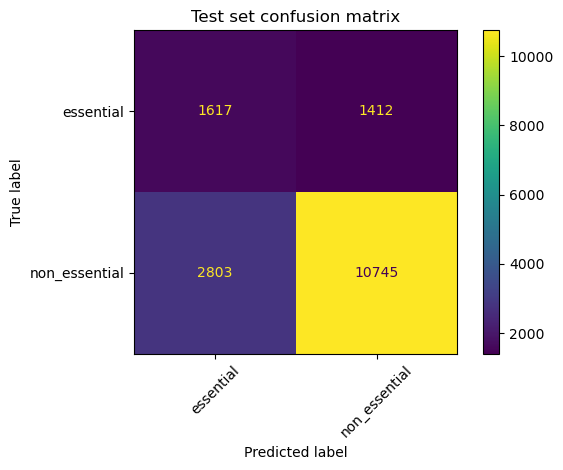

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(test_labels.numpy(), preds.numpy(), labels=list(range(n_classes)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45)
plt.title("Test set confusion matrix")
plt.tight_layout()
plt.show()

In [12]:
# Optional: save training history to JSON (same format as the script)
history_path = project_root / "figures" / f"training_history_{output_name}.json"
history_path.parent.mkdir(parents=True, exist_ok=True)
with open(history_path, "w") as f:
    json.dump({"train_losses": train_losses, "val_losses": val_losses, "val_metrics": val_metrics_history}, f, indent=2)
print(f"Saved history to {history_path}")

Saved history to /home/ds85/projects/GeneEssentiality/figures/training_history_notebook_model.json


## ProteomeLM-Ess style model (paper architecture)

Replicates the paper setup: **two-layer MLP** (embedding → hidden 2048 → ReLU → dropout 0.5 → 2 logits) and **genome-wide normalization** of embeddings (mean and std computed per proteome before the classifier). Uses the same binary config and train/val/test split as above; separate checkpoint and metrics.

In [36]:
# ProteomeLM-Ess: same binary config, genome-wide normalized embeddings
config_path_ess = project_root / "config" / "model_binary.yaml"
train_ds_ess, val_ds_ess, test_ds_ess = create_datasets_from_config(
    config_path_ess, normalize_by_organism=True
)
n_classes_ess = train_ds_ess.n_classes
with open(config_path_ess) as f:
    cfg_ess = yaml.safe_load(f)
class_names_ess = cfg_ess.get("classification", {}).get("class_names")
if not class_names_ess or len(class_names_ess) != n_classes_ess:
    class_names_ess = default_class_names(n_classes_ess)

print(f"ProteomeLM-Ess: classes={n_classes_ess} ({', '.join(class_names_ess)})")
print(f"Train: {len(train_ds_ess)}  Val: {len(val_ds_ess)}  Test: {len(test_ds_ess)}")

train_loader_ess = DataLoader(train_ds_ess, batch_size=batch_size, shuffle=True)
val_loader_ess = DataLoader(val_ds_ess, batch_size=batch_size, shuffle=False)
test_loader_ess = DataLoader(test_ds_ess, batch_size=batch_size, shuffle=False)

ProteomeLM-Ess: classes=2 (essential, non_essential)
Train: 78663  Val: 17620  Test: 16577


In [37]:
# Paper architecture: one hidden layer 2048, ReLU, dropout 0.5, 2 logits
loss_fn_ess = make_loss_fn(train_ds_ess.get_labels(), n_classes=n_classes_ess, device=device)
model_ess = EssentialityMLP(
    input_dim=train_ds_ess.embedding_dim,
    n_classes=n_classes_ess,
    hidden_dims=[2048],
    dropout=0.5,
).to(device)
optimizer_ess = torch.optim.AdamW(model_ess.parameters(), lr=lr, weight_decay=weight_decay)

In [38]:
output_name_ess = "notebook_model_ess"
use_auprc_ess = early_stop_on in ("auprc", "auprc_ae")
auprc_key_ess = f"auprc_{class_names_ess[0]}"
scheduler_ess = None
if use_scheduler:
    scheduler_ess = ReduceLROnPlateau(
        optimizer_ess, mode="max" if use_auprc_ess else "min",
        factor=scheduler_factor, patience=scheduler_patience,
    )

best_val_metric_ess = float("-inf") if use_auprc_ess else float("inf")
epochs_without_improvement_ess = 0
train_losses_ess, val_losses_ess, val_metrics_history_ess = [], [], []
checkpoint_path_ess = project_root / "models" / f"{output_name_ess}.pth"
checkpoint_path_ess.parent.mkdir(parents=True, exist_ok=True)

for epoch in range(epochs):
    train_loss = train_epoch(model_ess, train_loader_ess, loss_fn_ess, optimizer_ess, device)
    val_loss = eval_epoch(model_ess, val_loader_ess, loss_fn_ess, device)
    logits, labels = collect_predictions(model_ess, val_loader_ess, device)
    val_metrics = compute_metrics(logits, labels, n_classes=n_classes_ess, class_names=class_names_ess)

    metric_parts = [f"acc={val_metrics['accuracy']:.3f}", f"F1={val_metrics['weighted_f1']:.3f}"]
    for name in class_names_ess:
        v = val_metrics.get(f"auprc_{name}")
        metric_parts.append(f"AUPRC_{name[:4]}={v:.3f}" if isinstance(v, float) else f"AUPRC_{name[:4]}={v}")
    for name in class_names_ess:
        v = val_metrics.get(f"auroc_{name}")
        metric_parts.append(f"AUROC_{name[:4]}={v:.3f}" if isinstance(v, float) else f"AUROC_{name[:4]}={v}")
    lr_str = f" lr={optimizer_ess.param_groups[0]['lr']:.2e}" if scheduler_ess else ""
    print(f"Ess Epoch {epoch:3d}: train={train_loss:.4f} val={val_loss:.4f} | {' '.join(metric_parts)}{lr_str}")

    train_losses_ess.append(train_loss)
    val_losses_ess.append(val_loss)
    val_metrics_history_ess.append(val_metrics)

    if scheduler_ess is not None:
        if use_auprc_ess:
            scheduler_ess.step(val_metrics.get(auprc_key_ess) or 0.0)
        else:
            scheduler_ess.step(val_loss)

    if use_auprc_ess:
        current = val_metrics.get(auprc_key_ess) or 0.0
        improved = current > best_val_metric_ess
    else:
        current = val_loss
        improved = current < best_val_metric_ess

    if improved:
        best_val_metric_ess = current
        epochs_without_improvement_ess = 0
        torch.save(model_ess.state_dict(), checkpoint_path_ess)
    else:
        epochs_without_improvement_ess += 1

    if early_stopping is not None and epochs_without_improvement_ess >= early_stopping:
        print(f"Early stopping at epoch {epoch} (no improvement for {early_stopping} epochs)")
        break

Ess Epoch   0: train=0.6229 val=0.6132 | acc=0.674 F1=0.722 AUPRC_esse=0.361 AUPRC_non_=0.932 AUROC_esse=0.725 AUROC_non_=0.725 lr=1.00e-03
Ess Epoch   1: train=0.5935 val=0.5987 | acc=0.752 F1=0.781 AUPRC_esse=0.383 AUPRC_non_=0.936 AUROC_esse=0.740 AUROC_non_=0.740 lr=1.00e-03
Ess Epoch   2: train=0.5734 val=0.6205 | acc=0.659 F1=0.710 AUPRC_esse=0.382 AUPRC_non_=0.937 AUROC_esse=0.740 AUROC_non_=0.740 lr=1.00e-03
Ess Epoch   3: train=0.5630 val=0.6168 | acc=0.788 F1=0.805 AUPRC_esse=0.392 AUPRC_non_=0.940 AUROC_esse=0.746 AUROC_non_=0.746 lr=1.00e-03
Ess Epoch   4: train=0.5467 val=0.6154 | acc=0.765 F1=0.790 AUPRC_esse=0.404 AUPRC_non_=0.941 AUROC_esse=0.752 AUROC_non_=0.752 lr=1.00e-03
Ess Epoch   5: train=0.5330 val=0.6300 | acc=0.767 F1=0.791 AUPRC_esse=0.383 AUPRC_non_=0.938 AUROC_esse=0.744 AUROC_non_=0.744 lr=1.00e-03
Ess Epoch   6: train=0.5200 val=0.6253 | acc=0.763 F1=0.789 AUPRC_esse=0.402 AUPRC_non_=0.942 AUROC_esse=0.752 AUROC_non_=0.752 lr=1.00e-03
Ess Epoch   7: train

In [39]:
# Load best Ess checkpoint and evaluate on test set
model_ess.load_state_dict(torch.load(checkpoint_path_ess, map_location=device))
test_logits_ess, test_labels_ess = collect_predictions(model_ess, test_loader_ess, device)
test_metrics_ess = compute_metrics(
    test_logits_ess, test_labels_ess, n_classes=n_classes_ess, class_names=class_names_ess
)
print(f"=== ProteomeLM-Ess test set (checkpoint: {checkpoint_path_ess.name}) ===")
for k, v in sorted(test_metrics_ess.items()):
    if isinstance(v, float):
        print(f"  {k}: {v}")

=== ProteomeLM-Ess test set (checkpoint: notebook_model_ess.pth) ===
  accuracy: 0.8167340290764312
  auprc_essential: 0.44955227046107993
  auprc_non_essential: 0.9091320438989603
  auroc_essential: 0.7269773500390819
  auroc_non_essential: 0.7269663355597203
  weighted_f1: 0.8047036977699442


### Test metrics comparison

Table comparing test-set metrics across: (1) our original classification model, (2) ProteomeLM-Ess–style model on our data (genome-wide normalization, 2048/dropout 0.5 MLP), and (3) ProteomeLM-Ess from the paper (their data, split, and setup). Paper reports AUROC 0.93; other metrics not reported in the same form, so shown as —.

In [41]:
import pandas as pd

def _metric(m: dict | None, key: str):
    if m is None:
        return "—"
    v = m.get(key)
    if v is None:
        return "—"
    return round(v, 4) if isinstance(v, float) else v

rows = [
    {
        "Model": "Original (ours)",
        "accuracy": _metric(test_metrics, "accuracy"),
        "weighted_f1": _metric(test_metrics, "weighted_f1"),
        "AUROC (essential)": _metric(test_metrics, f"auroc_{class_names[0]}"),
        "AUROC (non_essential)": _metric(test_metrics, f"auroc_{class_names[1]}"),
        "AUPRC (essential)": _metric(test_metrics, f"auprc_{class_names[0]}"),
        "AUPRC (non_essential)": _metric(test_metrics, f"auprc_{class_names[1]}"),
    },
    {
        "Model": "ProteomeLM-Ess (ours)",
        "accuracy": _metric(test_metrics_ess, "accuracy"),
        "weighted_f1": _metric(test_metrics_ess, "weighted_f1"),
        "AUROC (essential)": _metric(test_metrics_ess, f"auroc_{class_names_ess[0]}"),
        "AUROC (non_essential)": _metric(test_metrics_ess, f"auroc_{class_names_ess[1]}"),
        "AUPRC (essential)": _metric(test_metrics_ess, f"auprc_{class_names_ess[0]}"),
        "AUPRC (non_essential)": _metric(test_metrics_ess, f"auprc_{class_names_ess[1]}"),
    },
    {
        "Model": "ProteomeLM-Ess (paper)",
        "accuracy": "—",
        "weighted_f1": "—",
        "AUROC (essential)": 0.93,
        "AUROC (non_essential)": "—",
        "AUPRC (essential)": "—",
        "AUPRC (non_essential)": "—",
    },
]
df_compare = pd.DataFrame(rows)
display(df_compare)

,Model,accuracy,weighted_f1,AUROC (essential),AUROC (non_essential),AUPRC (essential),AUPRC (non_essential)
0,Original (ours),0.7311,0.7515,0.7245,0.7245,0.4375,0.9076
1,ProteomeLM-Ess (ours),0.8167,0.8047,0.7270,0.727,0.4496,0.9091
2,ProteomeLM-Ess (paper),—,—,0.9300,—,—,—


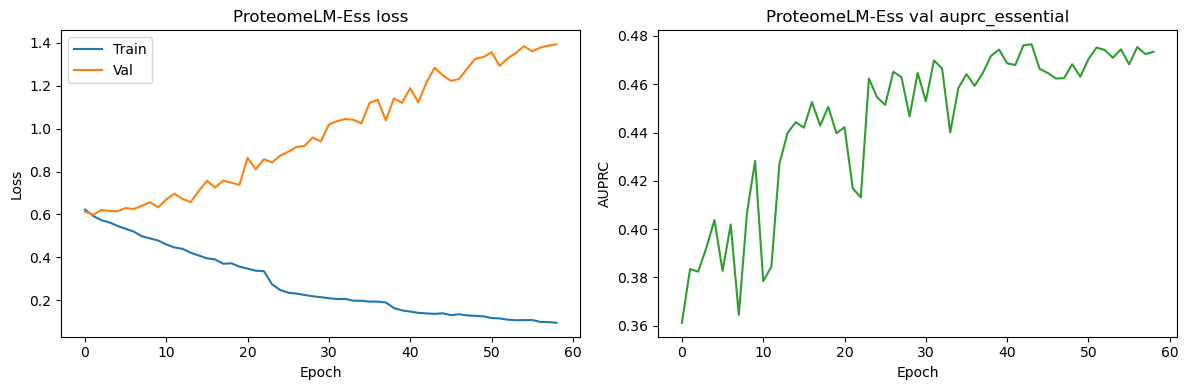

In [40]:
# Optional: plot ProteomeLM-Ess training curves
fig_ess, axes_ess = plt.subplots(1, 2, figsize=(12, 4))
axes_ess[0].plot(train_losses_ess, label="Train")
axes_ess[0].plot(val_losses_ess, label="Val")
axes_ess[0].set_xlabel("Epoch")
axes_ess[0].set_ylabel("Loss")
axes_ess[0].set_title("ProteomeLM-Ess loss")
axes_ess[0].legend()
auprc_vals_ess = [m.get(auprc_key_ess) if m.get(auprc_key_ess) is not None else float("nan") for m in val_metrics_history_ess]
axes_ess[1].plot(auprc_vals_ess, color="C2")
axes_ess[1].set_xlabel("Epoch")
axes_ess[1].set_ylabel("AUPRC")
axes_ess[1].set_title(f"ProteomeLM-Ess val {auprc_key_ess}")
plt.tight_layout()
plt.show()